The objective of this exercise was to identify the types of providers that struggle the most with filing claims.
The successful approval of claims is directly linked to the provider receiving revenue for their services.
Using public data from a sample of Medicare claims, this analysis reveals the provider types with the highest decline rates and the key denial reasons.
The top 5 provider types with the highest decline rates and root error code causes (excluding some that are not actionable) are: 
    - Medical supply company with orthotic personnel (47% Decline rate)
        - No Documentation	11% of Provider type errors
        - Medical Necessity	10%
    - Skilled Nursing Facility (32%)
        - Insufficient Documentation 7%
        - Incorrect Coding	2%
    - General Practice (32%)
        - Insufficient Documentation 15%
        - Medical Necessity	8%
        - No Documentation	4%
        - Incorrect Coding	2%
    - Nephrology (29%)
        - Incorrect Coding	14%
        - Insufficient Documentation	10%
        - No Documentation	3%
    - Pulmonary Disease (29%)
        - Incorrect Coding	15%
        - Insufficient Documentation	8%
        - No Documentation	3%

From this list, the most actionable recommendations for a health tech startup would be:
1. 19% of General Practice errors are due to documentation issues - Build documentation tools for General Practice doctors (e.g. voice dictation/ transcription from patient consultations that generates documentation about the session, including time stamps. Prompts when doctors are missing pieces required for treatment plans, signatures, etc. Workflow integration with the billing process to ensure documentation is attached every time.). After building a sufficient solution for general practice, other verticals similarly struggle with documentation issues (11% Orthotic Medical Supplies, 7% SNF, 10% Nephrology, 8% Pulmonary Disease)
2. 14% of Nephrology and 15% Pulmonary disease are denied due to incorrect coding - AI assisted coding can help reduce human error and accurately tag procedures to the codes that each insurer considers to be appropriate. Additional data needed to identify specific codes that cause these errors.

In [7]:
#Set up data - import libraries and load csv file
import pandas as pd
import sqlite3
file_name = "2025_Medicare_Claims_Errors.csv"
df = pd.read_csv(file_name)
df.head()

,claim_control_number,Part,DRG,HCPCS Procedure Code,Provider Type,Type of Bill,Review Decision,Error Code
0,2534105,2. DME MAC,NaN,K0739,"Medical supply company not included in 51, 52,...",NaN,Agree,-
1,2534105,2. DME MAC,NaN,E0955,"Medical supply company not included in 51, 52,...",NaN,Agree,-
2,2534105,2. DME MAC,NaN,E1028,"Medical supply company not included in 51, 52,...",NaN,Agree,-
3,2534105,2. DME MAC,NaN,K0108,"Medical supply company not included in 51, 52,...",NaN,Agree,-
4,2534105,2. DME MAC,NaN,K0108,"Medical supply company not included in 51, 52,...",NaN,Agree,-


In [8]:
#Set Up data - store csv data into claims table
conn = sqlite3.connect(":memory:")
df.to_sql("claims", conn, index=False, if_exists="replace")

163940

In [25]:
# Add columns
# conn.execute('ALTER TABLE claims ADD COLUMN Agree_Flag INTEGER DEFAULT 0;')
# conn.execute('ALTER TABLE claims ADD COLUMN Disagree_Flag INTEGER DEFAULT 0;')

# Update flags
conn.execute('UPDATE claims SET Agree_Flag = 1 WHERE "Review Decision" = "Agree";')
conn.execute('UPDATE claims SET Disagree_Flag = 1 WHERE "Review Decision" = "Disagree";')

# Commit changes
conn.commit()

In [26]:
#data explorer
query = """
SELECT *
FROM claims
LIMIT 10
"""

result = pd.read_sql(query, conn)
result

,claim_control_number,Part,DRG,HCPCS Procedure Code,Provider Type,Type of Bill,Review Decision,Error Code,Agree_Flag,Disagree_Flag
0,2534105,2. DME MAC,None,K0739,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
1,2534105,2. DME MAC,None,E0955,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
2,2534105,2. DME MAC,None,E1028,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
3,2534105,2. DME MAC,None,K0108,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
4,2534105,2. DME MAC,None,K0108,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
5,2534105,2. DME MAC,None,K0108,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
6,2534105,2. DME MAC,None,K0108,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
7,2534105,2. DME MAC,None,E2615,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
8,2534105,2. DME MAC,None,E2607,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0
9,2534105,2. DME MAC,None,E0954,"Medical supply company not included in 51, 52,...",None,Agree,-,1,0


In [81]:
###Drop Table if need to change it
# query= """
# DROP TABLE Top_Providers_by_Decline_Rate
# """
# conn.execute(query)
# conn.commit()

In [82]:
#Create a new table with top providers by decline rate
query = """
CREATE TABLE Top_Providers_by_Decline_Rate AS
SELECT  
    "Provider Type",
    SUM(Agree_Flag) AS Agree, 
    SUM(Disagree_Flag) AS Disagree, 
    SUM(Disagree_Flag) * 1.0 / (SUM(Agree_Flag) + SUM(Disagree_Flag)) AS Decline_Rate
FROM claims
GROUP BY "Provider Type"
Having Agree > 50
ORDER BY Decline_Rate DESC, Agree DESC;
"""

conn.execute(query)
conn.commit()

result = pd.read_sql("SELECT * FROM Top_Providers_by_Decline_Rate;", conn)
result

,Provider Type,Agree,Disagree,Decline_Rate
0,Medical supply company with orthotic personnel...,155,137,0.469178
1,Other FI Service Types,250,153,0.379653
2,SNF,9846,4676,0.321994
3,General Practice,160,74,0.316239
4,Nephrology,154,64,0.293578
...,...,...,...,...
74,Outpatient Rehab Facility (ORF),535,17,0.030797
75,Inpatient Critical Access Hospital,3872,93,0.023455
76,Non PPS Short Term Hospital Inpatient,1463,0,0.000000
77,Mass Immunization Roster Billers (Mass Immuniz...,162,0,0.000000


In [90]:
# Drop Table if need to change it
# query= """
# DROP TABLE Top_Providers_wErrorCode
# """
# conn.execute(query)
# conn.commit()

In [91]:
# For the top declined provider types (decline rate >25%), what are the reasons why (all rows related to top providers)
query = """
CREATE TABLE Top_Providers_wErrorCode AS
SELECT  c."Provider Type", c.claim_control_number, c."HCPCS Procedure Code", c."Agree_Flag", c."Disagree_Flag", c."Error Code", p.Decline_rate
FROM claims c
Join Top_Providers_by_Decline_Rate p on c."Provider Type" = p."Provider Type"
where p.decline_rate > 0.25
"""

conn.execute(query)
conn.commit()

In [85]:
#Data Exploration
query = """
SELECT distinct "Provider Type", Decline_rate
FROM Top_Providers_wErrorCode
"""

result = pd.read_sql(query, conn)
result

,Provider Type,Decline_Rate
0,Medical supply company with orthotic personnel...,0.469178
1,Other FI Service Types,0.379653
2,SNF,0.321994
3,General Practice,0.316239
4,Nephrology,0.293578
5,Pulmonary Disease,0.293478
6,Emergency Medicine,0.284047
7,Clinical Laboratory (Billing Independently),0.277276
8,Comprehensive Outpatient Rehab Facility (CORF),0.254310
9,Unknown Provider Type,0.251462


In [106]:
# For the top declined provider types, calculate the share that comes from each error type - load to Pandas
query = """
select "Provider Type", 
    CASE 
        WHEN "Error Code" = '-' THEN 'Approved'
        ELSE "Error Code"
    END AS "Error Code", 
    Count(*) as Error_Count,
    count(*)*1.0/ sum(count(*)) over(partition by "Provider Type") as Error_Share_of_Provider_Type
from Top_Providers_wErrorCode
group by "Provider Type", "Error Code"
Order by "Provider Type", "Error_Share_of_Provider_Type" desc
"""
result = pd.read_sql(query, conn)
result
# df = pd.read_sql(query, conn)

,Provider Type,Error Code,Error_Count,Error_Share_of_Provider_Type
0,Clinical Laboratory (Billing Independently),Approved,3429,0.720832
1,Clinical Laboratory (Billing Independently),Insufficient Documentation,949,0.199495
2,Clinical Laboratory (Billing Independently),No Documentation,305,0.064116
3,Clinical Laboratory (Billing Independently),Other,31,0.006517
4,Clinical Laboratory (Billing Independently),Medical Necessity,27,0.005676
5,Clinical Laboratory (Billing Independently),Overturned,9,0.001892
6,Clinical Laboratory (Billing Independently),Incorrect Coding,7,0.001472
7,Comprehensive Outpatient Rehab Facility (CORF),Approved,273,0.588362
8,Comprehensive Outpatient Rehab Facility (CORF),Insufficient Documentation,118,0.254310
9,Comprehensive Outpatient Rehab Facility (CORF),Overturned,73,0.157328


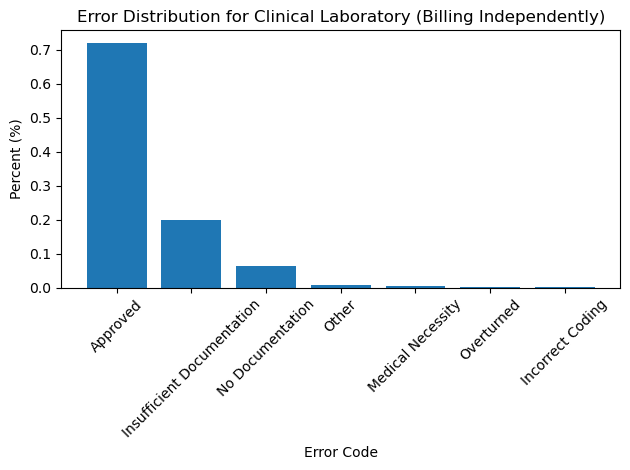

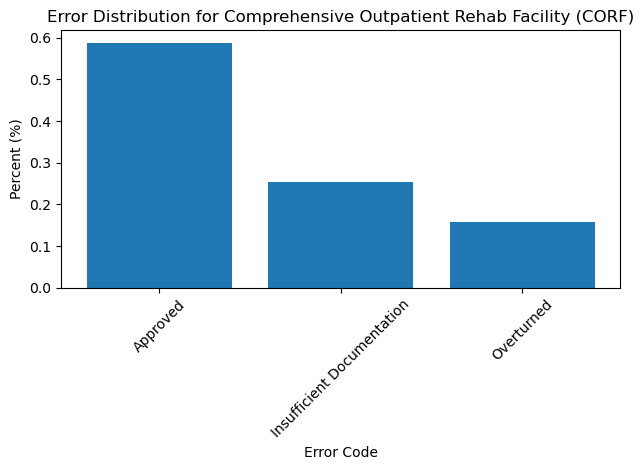

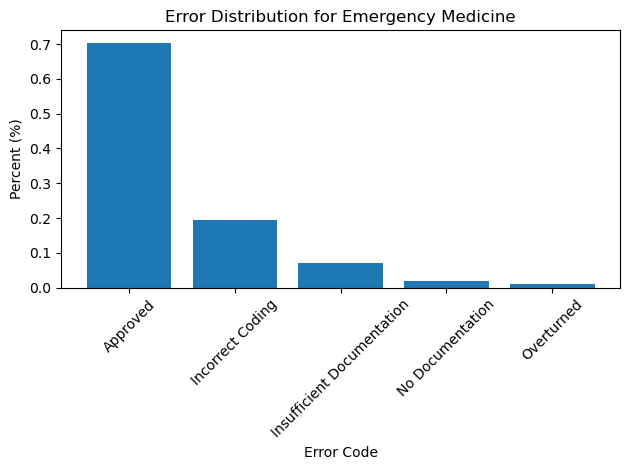

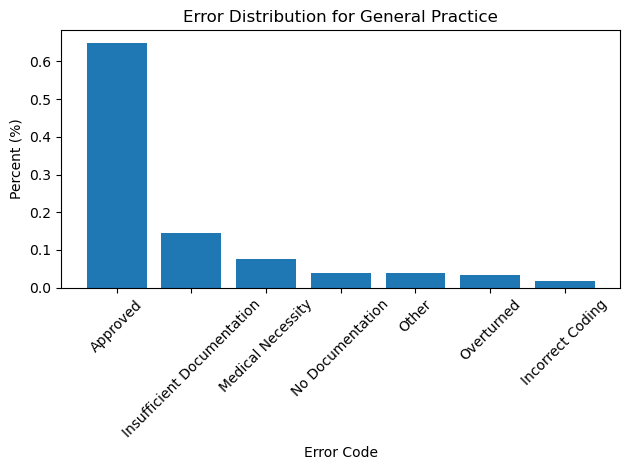

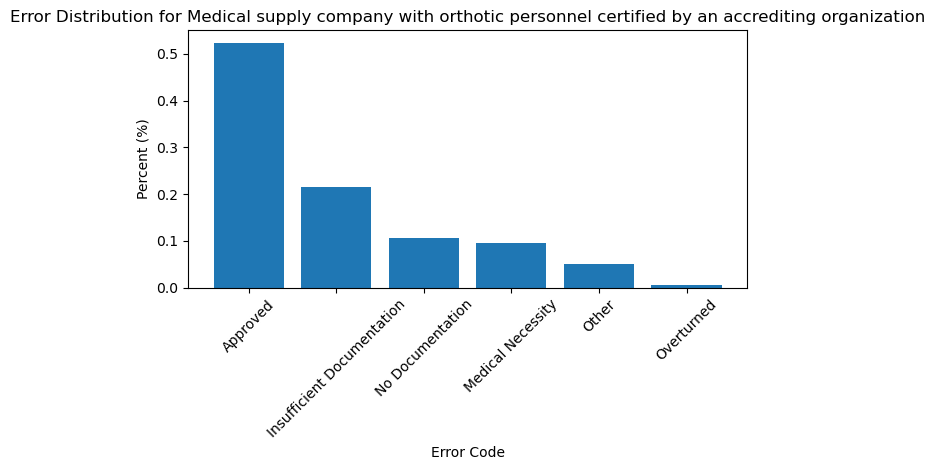

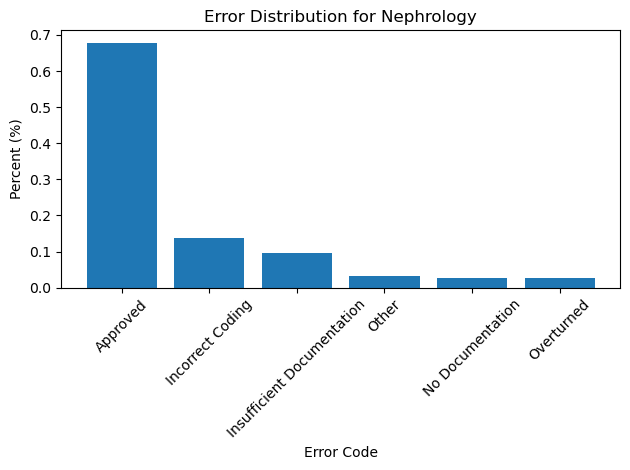

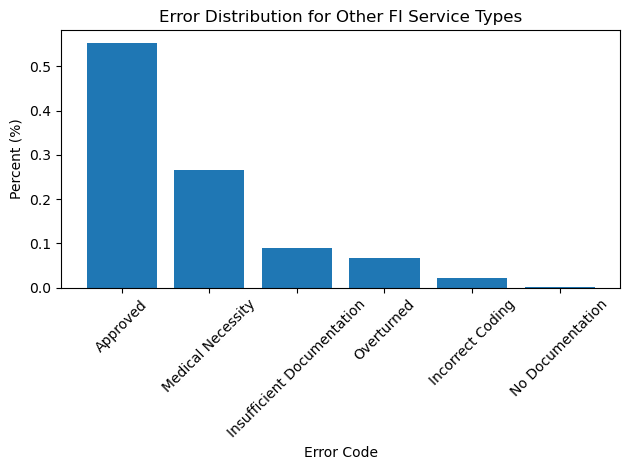

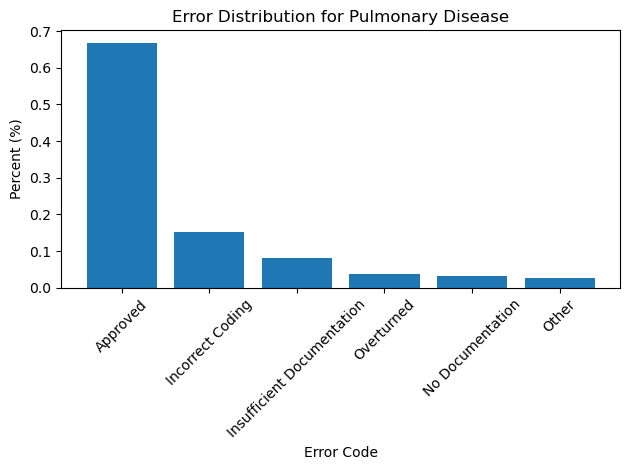

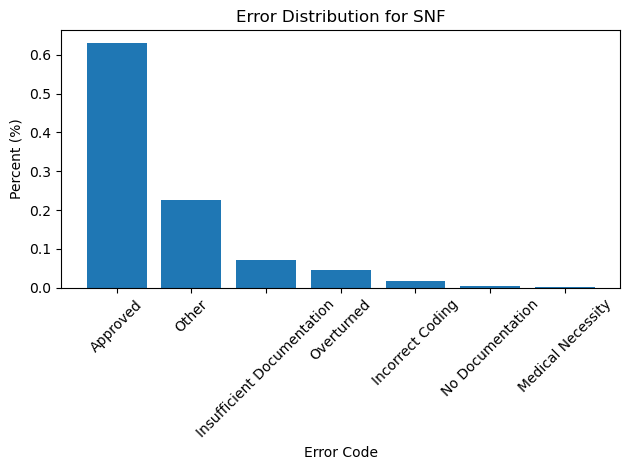

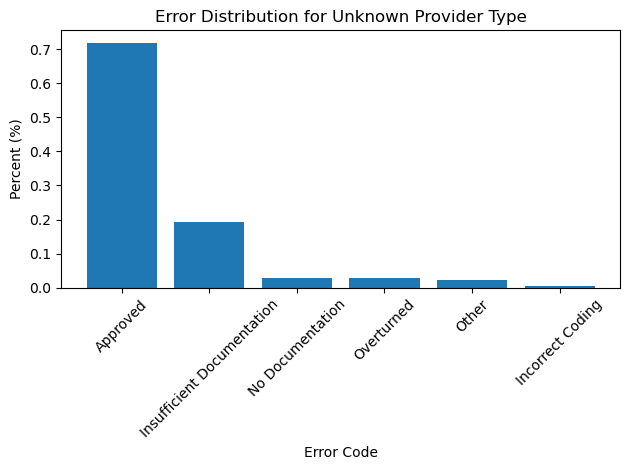

In [87]:
# visualize the results
import matplotlib.pyplot as plt

provider_types = df["Provider Type"].unique()

for provider in provider_types:
    subset = df[df["Provider Type"] == provider]
    
    plt.figure()
    plt.bar(subset["Error Code"], subset["Error_Share_of_Provider_Type"])
    plt.title(f"Error Distribution for {provider}")
    plt.xlabel("Error Code")
    plt.ylabel("Percent (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [99]:
# For the top declined provider types, calculate the share that comes from each HCPCS Procedure Code & the decline rate - load to Pandas
query = """
select "Provider Type", 
    "HCPCS Procedure Code",
    count (case when Disagree_Flag = 1 then 1 end) *1.0/ count(*) as Decline_Rate,
    count(*)*1.0/ sum(count(*)) over(partition by "Provider Type") as HCPCS_Share_of_Provider_Type,
    (count (case when Disagree_Flag = 1 then 1 end) *1.0/ count(*)) * (count(*)*1.0/ sum(count(*)) over(partition by "Provider Type")) as HCPCS_Error_Contribution
from Top_Providers_wErrorCode
group by "Provider Type", "HCPCS Procedure Code"
Order by "Provider Type", "HCPCS_Share_of_Provider_Type" desc
"""
# result = pd.read_sql(query, conn)
# result
df = pd.read_sql(query, conn)

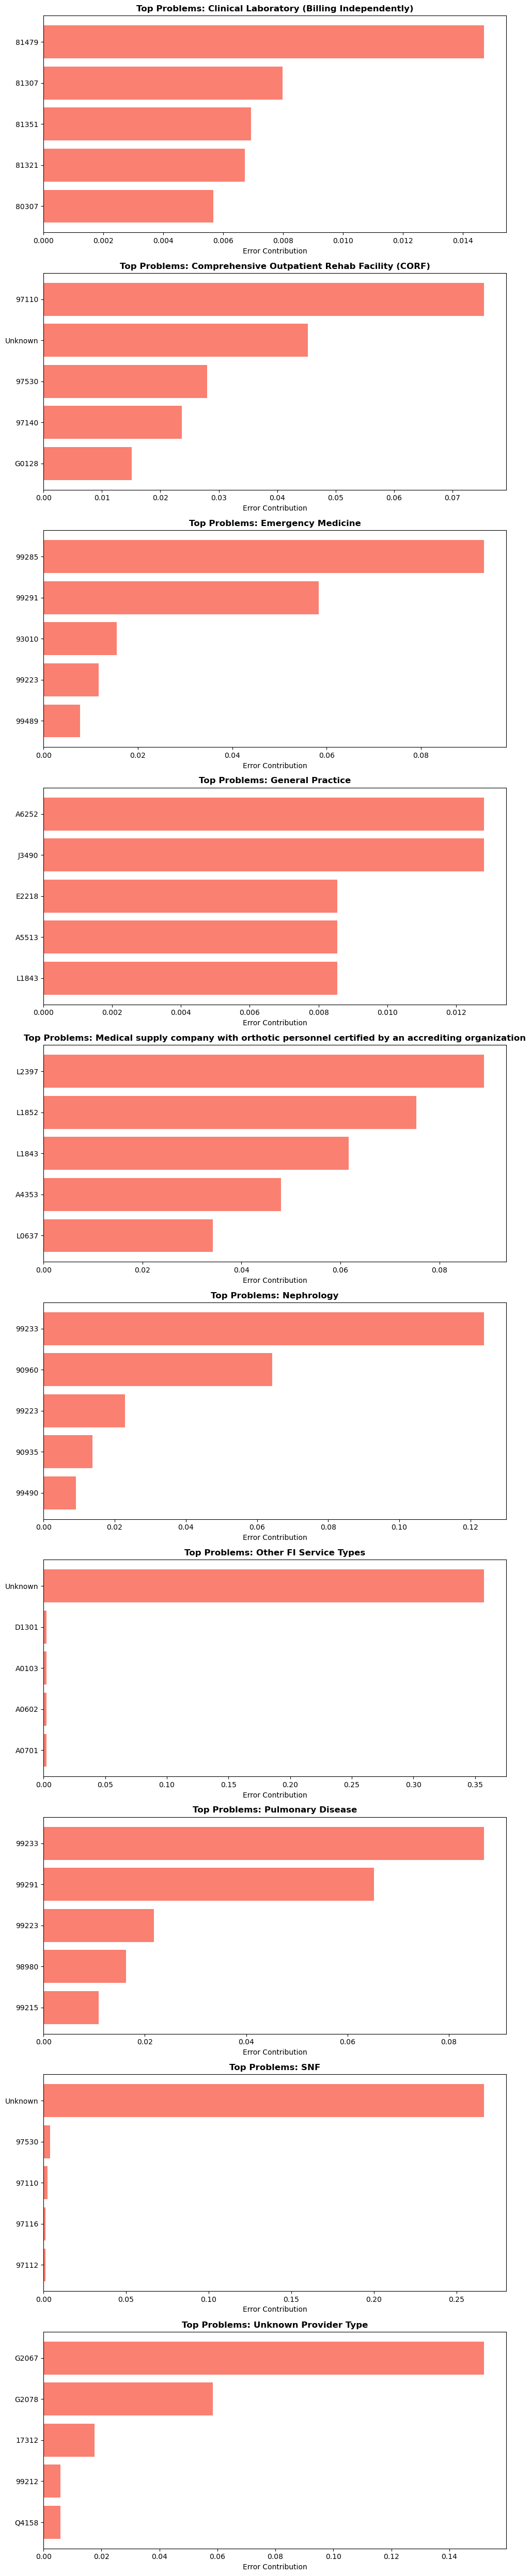

In [104]:
# visualize the results
import numpy as np

# 1. Clean the data: Convert None/NaN to a string like 'Unknown'
df['Provider Type'] = df['Provider Type'].fillna('Unknown').astype(str)
df['HCPCS Procedure Code'] = df['HCPCS Procedure Code'].fillna('Unknown').astype(str)

# 2. Get your unique providers
providers = df['Provider Type'].unique()
num_providers = len(providers)

# 3. Create subplots
fig, axes = plt.subplots(nrows=num_providers, figsize=(10, 5 * num_providers), squeeze=False)

for i, provider in enumerate(providers):
    # Use axes[i, 0] because squeeze=False ensures a 2D array
    ax = axes[i, 0]
    
    subset = df[df['Provider Type'] == provider].sort_values('HCPCS_Error_Contribution', ascending=True).tail(5)
    
    # Plotting
    ax.barh(subset['HCPCS Procedure Code'], subset['HCPCS_Error_Contribution'], color='salmon')
    ax.set_title(f"Top Problems: {provider}", fontweight='bold')
    ax.set_xlabel('Error Contribution')

plt.tight_layout()
plt.show()